# Vérification du Modèle de la Phase 0

Ce notebook permet de valider le contenu de l'artefact généré par la CI/CD ou l'entraînement automatisé.

In [1]:
import joblib

MODEL_PATH = "../model/scoring_model.joblib"
artefact = joblib.load(MODEL_PATH)
print("✅ Modèle chargé avec succès !")

✅ Modèle chargé avec succès !


## 1. Sélections des Variables


In [2]:
features = artefact["features"]
for i, f in enumerate(features):
    print(f"{i + 1}. {f}")

1. CREDIT_TERM
2. EXT_SOURCE_1
3. EXT_SOURCE_3
4. EXT_SOURCE_2
5. DAYS_BIRTH
6. DAYS_ID_PUBLISH
7. AMT_GOODS_PRICE
8. AMT_ANNUITY
9. AMT_CREDIT
10. DAYS_LAST_PHONE_CHANGE
11. DAYS_EMPLOYED_PERCENT
12. DAYS_REGISTRATION
13. YEARS_BIRTH
14. ANNUITY_INCOME_PERCENT
15. DAYS_EMPLOYED
16. CREDIT_INCOME_PERCENT
17. CODE_GENDER_M
18. OWN_CAR_AGE
19. AMT_INCOME_TOTAL
20. YEARS_EMPLOYED
21. REGION_POPULATION_RELATIVE
22. NAME_CONTRACT_TYPE_Revolvingloans
23. NAME_EDUCATION_TYPE_Highereducation
24. AMT_REQ_CREDIT_BUREAU_YEAR
25. FLAG_OWN_CAR_Y
26. REGION_RATING_CLIENT_W_CITY
27. AMT_REQ_CREDIT_BUREAU_QRT
28. NAME_FAMILY_STATUS_Married
29. HOUR_APPR_PROCESS_START
30. YEARS_BEGINEXPLUATATION_MODE
31. TOTALAREA_MODE
32. DEF_60_CNT_SOCIAL_CIRCLE
33. FLAG_DOCUMENT_3
34. NAME_EDUCATION_TYPE_Secondarysecondaryspecial
35. APARTMENTS_AVG
36. COMMONAREA_AVG
37. APARTMENTS_MODE
38. BASEMENTAREA_MODE
39. FLOORSMAX_AVG
40. OBS_60_CNT_SOCIAL_CIRCLE
41. REG_CITY_NOT_LIVE_CITY
42. BASEMENTAREA_AVG
43. OBS_30_CNT

## 2. Métriques & Optimisation Métier


In [4]:
metrics = artefact["metrics"]
print(f"⏱️ Temps d'entraînement: {metrics['training_time']:.2f} secondes")
print(f"⭐ Seuil optimal (FN=10): {metrics['best_threshold']:.3f}")
print(f"💰 Coût métier minimum : {metrics['min_business_cost']}")
print(f"ROC AUC : {metrics['roc_auc']:.4f}")
print(f"F1 Score: {metrics['f1_score']:.4f}")
print(f"Recall : {metrics['recall']:.4f}")
print(f"Precision : {metrics['precision']:.4f}")

⏱️ Temps d'entraînement: 5.60 secondes
⭐ Seuil optimal (FN=10): 0.101
💰 Coût métier minimum : 32683
ROC AUC : 0.7613
F1 Score: 0.2806
Recall : 0.6244
Precision : 0.1809


/var/folders/bn/w_0d71ld2yj2t6nh8mjr751c0000gn/T/ipykernel_40420/1867483756.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)
/Users/trikwi/openclassrooms/projet 8/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


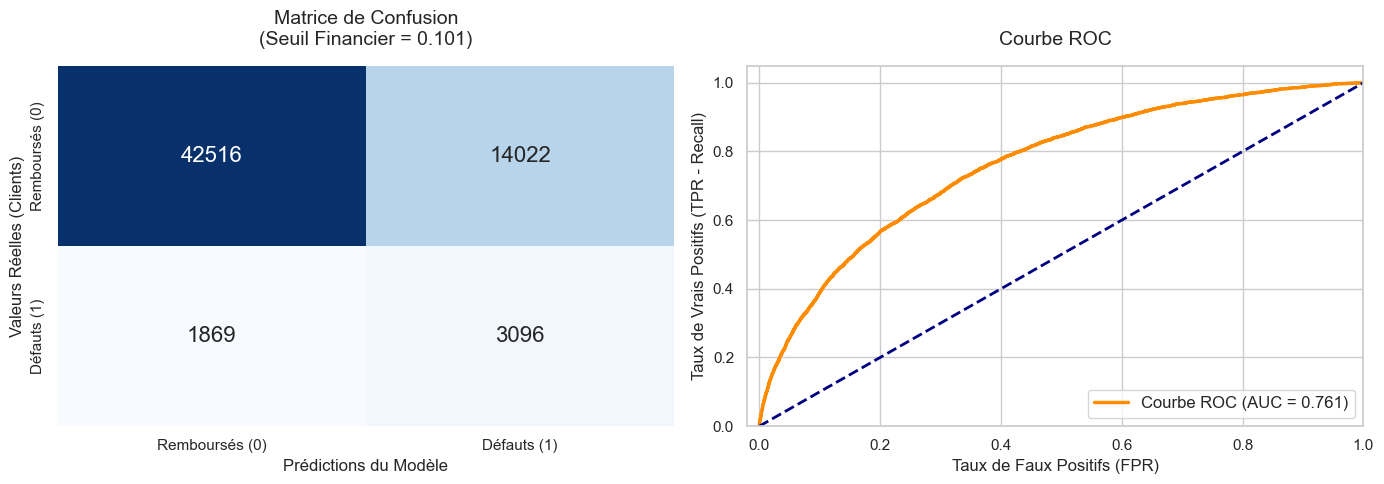

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import train_test_split
import re

# 1. On recharge les mêmes données de validation
DATA_PATH = "../internal_doc/Projet 6/Projet+Mise+en+prod+-+home-credit-default-risk/application_train.csv"
df = pd.read_csv(DATA_PATH)

# Feature Engineering Rapide (Identique à l'entrainement)
df["DAYS_EMPLOYED"].replace(365243, np.nan, inplace=True)
df["DAYS_EMPLOYED_PERCENT"] =  df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]
df["YEARS_EMPLOYED"] = df["DAYS_EMPLOYED"] / -365
df["YEARS_BIRTH"] = df["DAYS_BIRTH"] / -365
df["CREDIT_INCOME_PERCENT"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["ANNUITY_INCOME_PERCENT"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["CREDIT_TERM"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]

y = df["TARGET"]
X = df.drop(columns=["TARGET", "SK_ID_CURR"])

# Encodage One-hot & Nettoyage Noms
cat_columns = X.select_dtypes(include=["object"]).columns.tolist()
X = pd.get_dummies(X, columns=cat_columns, drop_first=True)
X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '', x))

# SPLIT IDENTIQUE (Seed 42)
_, X_val, _, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# On filtre uniquement sur les Top features de l'Artefact
X_val_top = X_val[artefact["features"]]

# 2. Prédiction via l'Artefact
X_val_imp = artefact["imputer"].transform(X_val_top)
y_proba = artefact["model"].predict_proba(X_val_imp)[:, 1]
best_t = artefact["metrics"]["best_threshold"]
y_pred = (y_proba >= best_t).astype(int)

# 3. Affichage Heatmap et ROC
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de Confusion (Heatmap)
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False, annot_kws={"size": 16})
ax1.set_title(f"Matrice de Confusion\n(Seuil Financier = {best_t:.3f})", fontsize=14, pad=15)
ax1.set_xlabel("Prédictions du Modèle", fontsize=12)
ax1.set_ylabel("Valeurs Réelles (Clients)", fontsize=12)
ax1.xaxis.set_ticklabels(['Remboursés (0)', 'Défauts (1)'])
ax1.yaxis.set_ticklabels(['Remboursés (0)', 'Défauts (1)'])

# Courbe ROC
fpr, tpr, _ = roc_curve(y_val, y_proba)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'Courbe ROC (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([-0.02, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)', fontsize=12)
ax2.set_title('Courbe ROC', fontsize=14, pad=15)
ax2.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

